# CDT v3.3.1 Training (Dropout 0.3)

**Version**: v3.3.1  
**Date**: 2025-12-14  
**Changes from v3.3**:
- DNA embeddings: `pilot_full_v2.h5` (5434 embeddings, correctly merged)
- Coordinate-based DNA mapping
- **Dropout: 0.3** (increased from 0.1 to reduce overfitting)

**Architecture**: Central Dogma (DNA -> RNA -> Protein) + VCE

**Goal**: Reduce overfitting and improve Val Pearson beyond 0.5019

**Previous results**:
- v3.3 (broken data): 0.4934
- v3.3.1 (dropout 0.1): 0.5019

## 1. Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Check GPU
!nvidia-smi

Sun Dec 14 14:04:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   29C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# Setup paths
import os
from pathlib import Path

# Colab data directory (local for faster access)
COLAB_DATA = Path("/content/colab_data_v3")
COLAB_DATA.mkdir(exist_ok=True)

# Drive paths
DRIVE_DATA = Path("/content/drive/MyDrive/cdt_data")
DRIVE_OUTPUT = Path("/content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03")
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)

print(f"COLAB_DATA: {COLAB_DATA}")
print(f"DRIVE_DATA: {DRIVE_DATA}")
print(f"DRIVE_OUTPUT: {DRIVE_OUTPUT}")

COLAB_DATA: /content/colab_data_v3
DRIVE_DATA: /content/drive/MyDrive/cdt_data
DRIVE_OUTPUT: /content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03


In [4]:
# Check available files on Drive
!ls -lh /content/drive/MyDrive/cdt_data/

total 108G
-rw------- 1 root root 6.7M Dec  7 16:40 human_proteomelm_embeddings_aligned.h5
-rw------- 1 root root 4.4M Dec  7 16:40 k562_gene_embeddings_aligned.h5
-rw------- 1 root root 144K Dec 12 14:04 missing_enhancers.tsv
-rw------- 1 root root  46G Dec 12 22:24 new_embeddings.h5
-rw------- 1 root root 9.6G Dec  7 16:40 pilot_1000.h5
-rw------- 1 root root  53G Dec 14 02:03 pilot_full_v2.h5
-rw------- 1 root root  56K Dec  7 17:13 protein_index_mapping_aligned.npz
drwx------ 2 root root 4.0K Dec 13 21:28 training


In [5]:
# Verify pilot_full_v2.h5
import h5py

with h5py.File('/content/drive/MyDrive/cdt_data/pilot_full_v2.h5', 'r') as f:
    centers = f['centers'][:]
    print(f"pilot_full_v2.h5:")
    print(f"  embeddings: {f['embeddings'].shape}")
    print(f"  Non-zero centers: {(centers != 0).sum()}/{len(centers)}")

    # Unique coordinates
    chroms = [c.decode() if isinstance(c, bytes) else c for c in f['chroms'][:]]
    coords = set((c, int(ctr)) for c, ctr in zip(chroms, centers))
    print(f"  Unique coordinates: {len(coords)}")

pilot_full_v2.h5:
  embeddings: (5434, 896, 3072)
  Non-zero centers: 5434/5434
  Unique coordinates: 5303


## 2. Copy Data to Local (Faster Training)

In [6]:
# Copy essential files to local storage
# Note: pilot_full_v2.h5 (56GB) is too large to copy, we'll access it directly from Drive

import shutil

files_to_copy = [
    "human_proteomelm_embeddings_aligned.h5",
    "k562_gene_embeddings_aligned.h5",
    "protein_index_mapping_aligned.npz",
]

# Training data folder
TRAINING_DIR = COLAB_DATA / "training"
TRAINING_DIR.mkdir(exist_ok=True)

training_files = [
    "gasperini_train.h5",
    "gasperini_val.h5",
]

print("Copying embedding files...")
for f in files_to_copy:
    src = DRIVE_DATA / f
    dst = COLAB_DATA / f
    if src.exists() and not dst.exists():
        print(f"  Copying {f}...")
        shutil.copy(src, dst)
    elif dst.exists():
        print(f"  {f} already exists")
    else:
        print(f"  WARNING: {f} not found on Drive!")

print("\nCopying training files...")
for f in training_files:
    src = DRIVE_DATA / "training" / f
    dst = TRAINING_DIR / f
    if src.exists() and not dst.exists():
        print(f"  Copying {f}...")
        shutil.copy(src, dst)
    elif dst.exists():
        print(f"  {f} already exists")
    else:
        print(f"  WARNING: {f} not found on Drive!")

print("\nDone!")

Copying embedding files...
  Copying human_proteomelm_embeddings_aligned.h5...
  Copying k562_gene_embeddings_aligned.h5...
  Copying protein_index_mapping_aligned.npz...

Copying training files...
  Copying gasperini_train.h5...
  Copying gasperini_val.h5...

Done!


In [7]:
# Verify local files
!ls -lh /content/colab_data_v3/
print()
!ls -lh /content/colab_data_v3/training/

total 12M
-rw------- 1 root root 6.7M Dec 14 14:08 human_proteomelm_embeddings_aligned.h5
-rw------- 1 root root 4.4M Dec 14 14:08 k562_gene_embeddings_aligned.h5
-rw------- 1 root root  56K Dec 14 14:08 protein_index_mapping_aligned.npz
drwxr-xr-x 2 root root 4.0K Dec 14 14:08 training

total 1.6M
-rw------- 1 root root 1.3M Dec 14 14:08 gasperini_train.h5
-rw------- 1 root root 282K Dec 14 14:08 gasperini_val.h5


## 3. Model and Dataset Code

In [8]:
# CDT v3.3 Model

import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Dict, Optional, Tuple


@dataclass
class CDTv33Config:
    """CDT v3.3 Config"""
    dna_dim: int = 3072
    dna_seq_len: int = 896
    protein_dim: int = 768
    rna_dim: int = 512
    n_proteins: int = 2360
    hidden_dim: int = 768
    nhead: int = 8
    dropout: float = 0.1
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1
    protein_self_attn_layers: int = 1


class SequenceProjector(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear(x)
        x = self.norm(x)
        x = self.dropout(x)
        return x


class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 4, dropout: float = 0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        attn_out, attn_weights = self.self_attn(
            x, x, x, need_weights=return_attention, average_attn_weights=False
        )
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x, attn_weights if return_attention else None


class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 4, dropout: float = 0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query: torch.Tensor, key_value: torch.Tensor):
        attn_out, attn_weights = self.cross_attn(
            query, key_value, key_value, need_weights=True, average_attn_weights=False
        )
        x = self.norm1(query + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x, attn_weights


class VirtualCellEmbedderWithAttention(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.dna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.rna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.protein_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.dna_attn = nn.MultiheadAttention(d_model, num_heads=4, dropout=dropout, batch_first=True)
        self.rna_attn = nn.MultiheadAttention(d_model, num_heads=4, dropout=dropout, batch_first=True)
        self.protein_attn = nn.MultiheadAttention(d_model, num_heads=4, dropout=dropout, batch_first=True)
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model)
        )

    def forward(self, dna_encoded, rna_encoded, protein_encoded):
        batch_size = dna_encoded.size(0)
        dna_query = self.dna_query.expand(batch_size, -1, -1)
        dna_pooled, _ = self.dna_attn(dna_query, dna_encoded, dna_encoded)
        dna_pooled = dna_pooled.squeeze(1)
        rna_query = self.rna_query.expand(batch_size, -1, -1)
        rna_pooled, _ = self.rna_attn(rna_query, rna_encoded, rna_encoded)
        rna_pooled = rna_pooled.squeeze(1)
        protein_query = self.protein_query.expand(batch_size, -1, -1)
        protein_pooled, _ = self.protein_attn(protein_query, protein_encoded, protein_encoded)
        protein_pooled = protein_pooled.squeeze(1)
        concat = torch.cat([dna_pooled, rna_pooled, protein_pooled], dim=-1)
        cell_embedding = self.fusion(concat)
        return cell_embedding


class CDTv33Model(nn.Module):
    """CDT v3.3: Central Dogma + VCE"""

    def __init__(self, config: Optional[CDTv33Config] = None):
        super().__init__()
        if config is None:
            config = CDTv33Config()
        self.config = config

        # Projectors
        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.rna_projector = SequenceProjector(config.rna_dim, config.hidden_dim, config.dropout)
        self.protein_projector = SequenceProjector(config.protein_dim, config.hidden_dim, config.dropout)

        # Self-Attention
        self.dna_self_attn_layers = nn.ModuleList([
            SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.dna_self_attn_layers)
        ])
        self.rna_self_attn_layers = nn.ModuleList([
            SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.rna_self_attn_layers)
        ])
        self.protein_self_attn_layers = nn.ModuleList([
            SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
            for _ in range(config.protein_self_attn_layers)
        ])

        # Cross-Attention (Central Dogma)
        self.dna_to_rna = CrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
        self.rna_to_protein = CrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)

        # VCE
        self.vce = VirtualCellEmbedderWithAttention(config.hidden_dim, config.dropout)

        # Task Layer
        self.task_layer = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.n_proteins)
        )

    def forward(self, dna_emb, protein_emb, rna_emb, return_attention=False):
        batch_size = dna_emb.size(0)
        attention_maps = {}

        # Projection
        dna = self.dna_projector(dna_emb)
        rna = self.rna_projector(rna_emb)
        protein = self.protein_projector(protein_emb)
        protein = protein.unsqueeze(0).expand(batch_size, -1, -1)

        # Self-Attention
        dna_self_attns = []
        for layer in self.dna_self_attn_layers:
            dna, attn = layer(dna, return_attention=return_attention)
            if return_attention and attn is not None:
                dna_self_attns.append(attn)
        if return_attention and dna_self_attns:
            attention_maps['dna_self_attn'] = dna_self_attns

        rna_self_attns = []
        for layer in self.rna_self_attn_layers:
            rna, attn = layer(rna, return_attention=return_attention)
            if return_attention and attn is not None:
                rna_self_attns.append(attn)
        if return_attention and rna_self_attns:
            attention_maps['rna_self_attn'] = rna_self_attns

        protein_self_attns = []
        for layer in self.protein_self_attn_layers:
            protein, attn = layer(protein, return_attention=return_attention)
            if return_attention and attn is not None:
                protein_self_attns.append(attn)
        if return_attention and protein_self_attns:
            attention_maps['protein_self_attn'] = protein_self_attns

        # Cross-Attention: DNA -> RNA
        rna_fused, dna_to_rna_attn = self.dna_to_rna(query=rna, key_value=dna)
        if return_attention:
            attention_maps['dna_to_rna'] = dna_to_rna_attn
        rna = rna_fused

        # Cross-Attention: RNA -> Protein
        protein_fused, rna_to_protein_attn = self.rna_to_protein(query=protein, key_value=rna)
        if return_attention:
            attention_maps['rna_to_protein'] = rna_to_protein_attn
        protein = protein_fused

        # VCE
        cell_embedding = self.vce(dna, rna, protein)

        # Task Layer
        logits = self.task_layer(cell_embedding)

        if return_attention:
            return logits, attention_maps
        return logits

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print("Model classes defined.")

Model classes defined.


In [9]:
# CDT v2 Dataset (with coordinate-based DNA mapping)
# IMPORTANT: Uses pilot_full_v2.h5 (correctly merged)

import torch
from torch.utils.data import Dataset, DataLoader
import h5py
import numpy as np
from pathlib import Path
from typing import Dict, List


class CDTv2Dataset(Dataset):
    """
    CDT v2 Dataset with coordinate-based DNA mapping

    v3.3.1: Uses pilot_full_v2.h5 (5434 embeddings, correctly merged)
    """

    def __init__(
        self,
        training_data_path: str,
        dna_seqlevel_path: str = None,
        proteomelm_path: str = None,
        rna_gene_path: str = None,
        project_root: str = None,
        n_proteins: int = None,
        use_aligned: bool = True,
    ):
        if project_root is None:
            project_root = Path("/content/colab_data_v3")

        self.project_root = Path(project_root)
        self.use_aligned = use_aligned

        # Default paths - v3.3.1 uses pilot_full_v2.h5 (FIXED!)
        if dna_seqlevel_path is None:
            dna_seqlevel_path = Path("/content/drive/MyDrive/cdt_data/pilot_full_v2.h5")
        if proteomelm_path is None:
            proteomelm_path = self.project_root / "human_proteomelm_embeddings_aligned.h5"
        if rna_gene_path is None:
            rna_gene_path = self.project_root / "k562_gene_embeddings_aligned.h5"

        self.training_data_path = Path(training_data_path)
        self.dna_seqlevel_path = Path(dna_seqlevel_path)
        self.proteomelm_path = Path(proteomelm_path)
        self.rna_gene_path = Path(rna_gene_path)
        self.n_proteins_limit = n_proteins

        # Load index mapping
        if use_aligned:
            self._load_index_mapping()

        # Load data
        self._load_training_data()
        self._load_embeddings()

    def _load_index_mapping(self):
        mapping_path = self.project_root / "protein_index_mapping_aligned.npz"
        data = np.load(mapping_path, allow_pickle=True)
        old_to_new_pairs = data['old_to_new']
        self.old_to_new_idx = {int(pair[0]): int(pair[1]) for pair in old_to_new_pairs}
        print(f"Loaded protein index mapping: {len(self.old_to_new_idx)} proteins")

    def _load_training_data(self):
        with h5py.File(self.training_data_path, 'r') as f:
            enformer_idx = f['enformer_idx'][:]
            orig_protein_idx = f['esm2_idx'][:]
            labels = f['labels'][:]
            if 'beta' in f:
                beta_values = f['beta'][:]
            else:
                beta_values = np.zeros_like(labels, dtype=np.float32)

            self.enhancer_chr = [c.decode() if isinstance(c, bytes) else c
                                 for c in f['enhancer_chr'][:]]
            self.enhancer_start = f['enhancer_start'][:]
            self.enhancer_end = f['enhancer_end'][:]

        if self.use_aligned:
            valid_mask = np.array([int(idx) in self.old_to_new_idx for idx in orig_protein_idx])
            self.enformer_idx = enformer_idx[valid_mask]
            self.labels = labels[valid_mask]
            self.beta_values = beta_values[valid_mask]
            self.enhancer_chr = [c for c, v in zip(self.enhancer_chr, valid_mask) if v]
            self.enhancer_start = self.enhancer_start[valid_mask]
            self.enhancer_end = self.enhancer_end[valid_mask]
            valid_orig_idx = orig_protein_idx[valid_mask]
            self.protein_idx = np.array([self.old_to_new_idx[int(idx)] for idx in valid_orig_idx])
            n_filtered = len(orig_protein_idx) - valid_mask.sum()
            print(f"Filtered {n_filtered} samples (no matching protein)")
        else:
            self.enformer_idx = enformer_idx
            self.labels = labels
            self.beta_values = beta_values
            self.protein_idx = orig_protein_idx

        self.n_samples = len(self.labels)
        self.n_positive = int(np.sum(self.labels))
        self.n_negative = self.n_samples - self.n_positive
        print(f"Training data: {self.n_samples} samples ({self.n_positive} positive)")

    def _load_embeddings(self):
        # DNA embeddings
        self.dna_file = h5py.File(self.dna_seqlevel_path, 'r')
        self.dna_emb = self.dna_file['embeddings']
        self.dna_seq_len = self.dna_emb.shape[1]
        self.dna_dim = self.dna_emb.shape[2]
        self.dna_centers = self.dna_file['centers'][:]
        self.dna_chroms = [c.decode() if isinstance(c, bytes) else c
                          for c in self.dna_file['chroms'][:]]

        print(f"DNA embeddings: {self.dna_emb.shape}")

        # Verify DNA data integrity
        non_zero = (self.dna_centers != 0).sum()
        print(f"DNA non-zero centers: {non_zero}/{len(self.dna_centers)}")
        if non_zero < len(self.dna_centers) * 0.9:
            print("WARNING: Many zero centers! Data may be corrupted.")

        # Protein embeddings
        with h5py.File(self.proteomelm_path, 'r') as f:
            self.protein_emb = f['embeddings'][:]
            self.protein_ids = [x.decode() if isinstance(x, bytes) else x
                                for x in f['uniprot_ids'][:]]
            self.protein_gene_names = [x.decode() if isinstance(x, bytes) else x
                                        for x in f['gene_names'][:]]

        if self.n_proteins_limit is not None:
            self.protein_emb = self.protein_emb[:self.n_proteins_limit]

        self.n_proteins = len(self.protein_emb)
        self.protein_dim = self.protein_emb.shape[1]

        # RNA embeddings
        with h5py.File(self.rna_gene_path, 'r') as f:
            self.rna_emb = f['embeddings'][:]
            self.rna_gene_names = [x.decode() if isinstance(x, bytes) else x
                                   for x in f['gene_names'][:]]

        self.n_genes = self.rna_emb.shape[0]
        self.rna_dim = self.rna_emb.shape[1]

        print(f"Protein embeddings: {self.protein_emb.shape}")
        print(f"RNA gene embeddings: {self.rna_emb.shape}")

        # Create coordinate-based DNA mapping
        self._create_dna_index_mapping()

    def _create_dna_index_mapping(self):
        """Coordinate-based DNA mapping"""
        dna_coord_to_idx = {}
        for dna_idx, (chrom, center) in enumerate(zip(self.dna_chroms, self.dna_centers)):
            dna_coord_to_idx[(chrom, int(center))] = dna_idx

        self.sample_to_dna_idx = {}
        matched_count = 0
        tolerance = 1000

        for sample_idx in range(len(self.enhancer_chr)):
            chrom = self.enhancer_chr[sample_idx]
            center = (self.enhancer_start[sample_idx] + self.enhancer_end[sample_idx]) // 2

            if (chrom, center) in dna_coord_to_idx:
                self.sample_to_dna_idx[sample_idx] = dna_coord_to_idx[(chrom, center)]
                matched_count += 1
            else:
                found = False
                for dna_key, dna_idx in dna_coord_to_idx.items():
                    if dna_key[0] == chrom and abs(dna_key[1] - center) <= tolerance:
                        self.sample_to_dna_idx[sample_idx] = dna_idx
                        matched_count += 1
                        found = True
                        break
                if not found:
                    self.sample_to_dna_idx[sample_idx] = None

        match_rate = matched_count / len(self.enhancer_chr) * 100
        print(f"DNA coordinate mapping: {matched_count}/{len(self.enhancer_chr)} samples matched ({match_rate:.1f}%)")

        # IMPORTANT: Check match rate
        if match_rate < 50:
            print("WARNING: Low match rate! Check coordinate alignment.")

    def _get_dna_emb_by_sample_idx(self, sample_idx: int) -> np.ndarray:
        dna_idx = self.sample_to_dna_idx.get(sample_idx)
        if dna_idx is not None:
            return self.dna_emb[dna_idx, :, :].astype(np.float32)
        else:
            return np.zeros((self.dna_seq_len, self.dna_dim), dtype=np.float32)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx: int):
        dna_emb = self._get_dna_emb_by_sample_idx(idx)
        rna_emb = self.rna_emb.astype(np.float32)
        prot_idx = int(self.protein_idx[idx])
        label = self.labels[idx]
        beta = self.beta_values[idx]

        return {
            'dna_emb': torch.from_numpy(dna_emb),
            'rna_emb': torch.from_numpy(rna_emb),
            'protein_idx': torch.tensor(prot_idx, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.float32),
            'beta': torch.tensor(beta, dtype=torch.float32),
        }

    def get_protein_embeddings(self):
        return torch.from_numpy(self.protein_emb.astype(np.float32))

    def close(self):
        try:
            if hasattr(self, 'dna_file') and self.dna_file:
                self.dna_file.close()
        except:
            pass


def collate_v2(batch: List[Dict]):
    dna_embs = torch.stack([item['dna_emb'] for item in batch])
    rna_embs = torch.stack([item['rna_emb'] for item in batch])
    protein_indices = torch.stack([item['protein_idx'] for item in batch])
    labels = torch.stack([item['label'] for item in batch])
    betas = torch.stack([item['beta'] for item in batch])
    return {
        'dna_emb': dna_embs,
        'rna_emb': rna_embs,
        'protein_indices': protein_indices,
        'labels': labels,
        'betas': betas,
    }


print("Dataset classes defined.")

Dataset classes defined.


## 4. Training Functions

In [10]:
# Training utilities

import torch.optim as optim
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm
import json
from datetime import datetime


def compute_regression_metrics(pred, target):
    ss_res = np.sum((target - pred) ** 2)
    ss_tot = np.sum((target - target.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    pearson_r, pearson_p = pearsonr(pred, target)
    spearman_r, spearman_p = spearmanr(pred, target)
    mse = np.mean((pred - target) ** 2)
    mae = np.mean(np.abs(pred - target))
    return {
        'r2': float(r2),
        'pearson_r': float(pearson_r),
        'pearson_p': float(pearson_p),
        'spearman_r': float(spearman_r),
        'spearman_p': float(spearman_p),
        'mse': float(mse),
        'mae': float(mae)
    }


def train_epoch(model, train_loader, criterion, optimizer, device, protein_emb):
    model.train()
    total_loss = 0
    all_targets = []
    all_preds = []

    for batch in tqdm(train_loader, desc="Training", leave=False):
        dna = batch['dna_emb'].to(device)
        rna = batch['rna_emb'].to(device)
        protein_indices = batch['protein_indices'].to(device)
        betas = batch['betas'].to(device)

        optimizer.zero_grad()
        logits = model(dna, protein_emb, rna)

        batch_size = dna.size(0)
        pred = logits[range(batch_size), protein_indices]

        loss = criterion(pred, betas)
        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(pred.detach().cpu().numpy())
        all_targets.extend(betas.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    metrics = compute_regression_metrics(np.array(all_preds), np.array(all_targets))
    return avg_loss, metrics


def evaluate(model, data_loader, criterion, device, protein_emb, return_attention=False):
    model.eval()
    total_loss = 0
    all_targets = []
    all_preds = []
    all_attention = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            dna = batch['dna_emb'].to(device)
            rna = batch['rna_emb'].to(device)
            protein_indices = batch['protein_indices'].to(device)
            betas = batch['betas'].to(device)

            batch_size = dna.size(0)

            if return_attention:
                logits, attention = model(dna, protein_emb, rna, return_attention=True)
                pred = logits[range(batch_size), protein_indices]
                all_attention.append({
                    k: (v.cpu().numpy() if not isinstance(v, list) else [x.cpu().numpy() for x in v])
                    for k, v in attention.items()
                })
            else:
                logits = model(dna, protein_emb, rna)
                pred = logits[range(batch_size), protein_indices]

            loss = criterion(pred, betas)
            total_loss += loss.item()
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(betas.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    metrics = compute_regression_metrics(np.array(all_preds), np.array(all_targets))

    if return_attention:
        return avg_loss, metrics, all_attention
    return avg_loss, metrics


class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_score: float) -> bool:
        if self.best_score is None:
            self.best_score = val_score
        elif val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_score
            self.counter = 0
        return self.early_stop


print("Training utilities defined.")

Training utilities defined.


## 5. Run Training

In [11]:
# Main training

print("=" * 60)
print("CDT v3.3.1 Training (Central Dogma + VCE) - Dropout 0.3")
print("=" * 60)
print("Changes from v3.3:")
print("  - DNA: pilot_full_v2.h5 (5434 embeddings, correctly merged)")
print("  - Coordinate-based DNA mapping")
print("  - Dropout: 0.3 (increased from 0.1)")
print("=" * 60)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Hyperparameters
config = {
    'batch_size': 8,
    'hidden_dim': 768,
    'nhead': 8,
    'dropout': 0.3,  # Increased from 0.1
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'epochs': 50,
    'patience': 10,
    'huber_delta': 1.0,
    'grad_clip_norm': 1.0,
}
print(f"\nConfig: {json.dumps(config, indent=2)}")

CDT v3.3.1 Training (Central Dogma + VCE) - Dropout 0.3
Changes from v3.3:
  - DNA: pilot_full_v2.h5 (5434 embeddings, correctly merged)
  - Coordinate-based DNA mapping
  - Dropout: 0.3 (increased from 0.1)
Using CUDA: NVIDIA A100-SXM4-40GB

Config: {
  "batch_size": 8,
  "hidden_dim": 768,
  "nhead": 8,
  "dropout": 0.3,
  "learning_rate": 0.0001,
  "weight_decay": 1e-05,
  "epochs": 50,
  "patience": 10,
  "huber_delta": 1.0,
  "grad_clip_norm": 1.0
}


In [12]:
# Create datasets
print("\n[Dataset]")

train_dataset = CDTv2Dataset(
    TRAINING_DIR / "gasperini_train.h5",
    project_root=COLAB_DATA,
    use_aligned=True
)

val_dataset = CDTv2Dataset(
    TRAINING_DIR / "gasperini_val.h5",
    project_root=COLAB_DATA,
    use_aligned=True
)

# Beta statistics
print(f"\n[Beta Statistics]")
beta_vals = train_dataset.beta_values
print(f"  min: {beta_vals.min():.4f}, max: {beta_vals.max():.4f}")
print(f"  mean: {beta_vals.mean():.4f}, std: {beta_vals.std():.4f}")
print(f"  non-zero: {(beta_vals != 0).sum()}/{len(beta_vals)}")

# Protein embeddings (shared)
protein_emb = train_dataset.get_protein_embeddings().to(device)
print(f"  Protein embeddings: {protein_emb.shape}")


[Dataset]
Loaded protein index mapping: 2364 proteins
Filtered 25096 samples (no matching protein)
Training data: 4605 samples (44 positive)
DNA embeddings: (5434, 896, 3072)
DNA non-zero centers: 5434/5434
Protein embeddings: (2360, 768)
RNA gene embeddings: (2360, 512)
DNA coordinate mapping: 4605/4605 samples matched (100.0%)
Loaded protein index mapping: 2364 proteins
Filtered 5368 samples (no matching protein)
Training data: 996 samples (12 positive)
DNA embeddings: (5434, 896, 3072)
DNA non-zero centers: 5434/5434
Protein embeddings: (2360, 768)
RNA gene embeddings: (2360, 512)
DNA coordinate mapping: 985/996 samples matched (98.9%)

[Beta Statistics]
  min: -3.6938, max: -0.0000
  mean: -0.1087, std: 0.1935
  non-zero: 4605/4605
  Protein embeddings: torch.Size([2360, 768])


In [13]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=0,
    collate_fn=collate_v2,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=0,
    collate_fn=collate_v2
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Sample check
sample = train_dataset[0]
print(f"\nSample shapes:")
print(f"  DNA: {sample['dna_emb'].shape}")
print(f"  RNA: {sample['rna_emb'].shape}")
print(f"  Protein idx: {sample['protein_idx']}")
print(f"  Beta: {sample['beta']}")

Train batches: 575
Val batches: 125

Sample shapes:
  DNA: torch.Size([896, 3072])
  RNA: torch.Size([2360, 512])
  Protein idx: 1779
  Beta: -0.028697989881038666


In [14]:
# Create model
print("\n[Model - CDTv33Model]")
print("  Central Dogma: DNA -> RNA -> Protein")
print("  VCE: Attention Pooling")
print(f"  Gradient Clipping: max_norm={config['grad_clip_norm']}")

model_config = CDTv33Config(
    dna_dim=sample['dna_emb'].shape[-1],
    dna_seq_len=sample['dna_emb'].shape[0],
    protein_dim=protein_emb.shape[-1],
    rna_dim=sample['rna_emb'].shape[-1],
    n_proteins=protein_emb.shape[0],
    hidden_dim=config['hidden_dim'],
    nhead=config['nhead'],
    dropout=config['dropout']
)
model = CDTv33Model(model_config).to(device)

print(f"Model params: {model.get_num_params():,}")


[Model - CDTv33Model]
  Central Dogma: DNA -> RNA -> Protein
  VCE: Attention Pooling
  Gradient Clipping: max_norm=1.0
Model params: 60,093,752


In [15]:
# Loss, optimizer, scheduler
criterion = nn.SmoothL1Loss(beta=config['huber_delta'])

optimizer = optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

early_stopping = EarlyStopping(patience=config['patience'])

print("Loss: Huber Loss")
print("Optimizer: AdamW")
print("Scheduler: ReduceLROnPlateau")

Loss: Huber Loss
Optimizer: AdamW
Scheduler: ReduceLROnPlateau


In [16]:
# Training loop
print("\n[Training Start]")
best_pearson = -1
history = {
    'train_loss': [], 'train_r2': [], 'train_pearson': [],
    'val_loss': [], 'val_r2': [], 'val_pearson': []
}

for epoch in range(config['epochs']):
    print(f"\nEpoch {epoch+1}/{config['epochs']}")

    # Train
    train_loss, train_metrics = train_epoch(
        model, train_loader, criterion, optimizer, device, protein_emb
    )
    print(f"  Train - Loss: {train_loss:.4f}, R2: {train_metrics['r2']:.4f}, "
          f"Pearson: {train_metrics['pearson_r']:.4f}")

    # Validate
    val_loss, val_metrics = evaluate(
        model, val_loader, criterion, device, protein_emb
    )
    print(f"  Val   - Loss: {val_loss:.4f}, R2: {val_metrics['r2']:.4f}, "
          f"Pearson: {val_metrics['pearson_r']:.4f}")

    # History
    history['train_loss'].append(train_loss)
    history['train_r2'].append(train_metrics['r2'])
    history['train_pearson'].append(train_metrics['pearson_r'])
    history['val_loss'].append(val_loss)
    history['val_r2'].append(val_metrics['r2'])
    history['val_pearson'].append(val_metrics['pearson_r'])

    # Scheduler
    scheduler.step(val_metrics['pearson_r'])

    # Save best model
    if val_metrics['pearson_r'] > best_pearson:
        best_pearson = val_metrics['pearson_r']
        torch.save(model.state_dict(), DRIVE_OUTPUT / "cdt_v3_3_1_dropout03_best.pt")
        print(f"  * Saved best model (Pearson: {best_pearson:.4f})")

    # Early stopping
    if early_stopping(val_metrics['pearson_r']):
        print(f"  Early stopping at epoch {epoch+1}")
        break

print("\n" + "=" * 60)
print(f"Training Complete! Best Pearson: {best_pearson:.4f}")
print("=" * 60)


[Training Start]

Epoch 1/50


  Train - Loss: 0.0276, R2: -0.5946, Pearson: 0.1268


  Val   - Loss: 0.0123, R2: -0.1057, Pearson: 0.3128
  * Saved best model (Pearson: 0.3128)

Epoch 2/50


  Train - Loss: 0.0168, R2: -0.0167, Pearson: 0.3198


  Val   - Loss: 0.0116, R2: -0.0428, Pearson: 0.3872
  * Saved best model (Pearson: 0.3872)

Epoch 3/50


...

  Val   - Loss: 0.0096, R2: 0.1354, Pearson: 0.5014

Epoch 25/50


  Train - Loss: 0.0094, R2: 0.4341, Pearson: 0.6592


  Val   - Loss: 0.0097, R2: 0.1229, Pearson: 0.5008

Epoch 26/50


  Train - Loss: 0.0095, R2: 0.4243, Pearson: 0.6521


  Val   - Loss: 0.0099, R2: 0.1128, Pearson: 0.5007
  Early stopping at epoch 26

Training Complete! Best Pearson: 0.5032


## 6. Final Evaluation

In [17]:
# Final evaluation
print("\n[Final Evaluation]")
model.load_state_dict(torch.load(DRIVE_OUTPUT / "cdt_v3_3_1_dropout03_best.pt"))

final_loss, final_metrics = evaluate(
    model, val_loader, criterion, device, protein_emb
)

print(f"Final Val Metrics:")
print(f"  Loss: {final_loss:.4f}")
print(f"  R2: {final_metrics['r2']:.4f}")
print(f"  Pearson r: {final_metrics['pearson_r']:.4f} (p={final_metrics['pearson_p']:.2e})")
print(f"  Spearman r: {final_metrics['spearman_r']:.4f} (p={final_metrics['spearman_p']:.2e})")
print(f"  MSE: {final_metrics['mse']:.4f}")
print(f"  MAE: {final_metrics['mae']:.4f}")


[Final Evaluation]


Final Val Metrics:
  Loss: 0.0100
  R2: 0.1036
  Pearson r: 0.5032 (p=4.83e-65)
  Spearman r: 0.4463 (p=6.31e-50)
  MSE: 0.0200
  MAE: 0.0808


In [18]:
# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results = {
    'version': 'v3.3.1_dropout03',
    'architecture': 'Central Dogma + VCE',
    'changes': [
        'DNA embeddings: pilot_full_v2.h5 (5434 embeddings, correctly merged)',
        'Coordinate-based DNA mapping',
        'Dropout: 0.3 (increased from 0.1)',
    ],
    'config': config,
    'final_metrics': final_metrics,
    'best_pearson': float(best_pearson),
    'history': {k: [float(v) for v in vals] for k, vals in history.items()}
}

with open(DRIVE_OUTPUT / f"results_{timestamp}.json", 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to: {DRIVE_OUTPUT}")


Results saved to: /content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03


In [19]:
# Cleanup
train_dataset.close()
val_dataset.close()

print("\n" + "=" * 60)
print("CDT v3.3.1 Training Complete! (Dropout 0.3)")
print(f"  Best Pearson: {best_pearson:.4f}")
print(f"  (v3.3.1 dropout 0.1 was 0.5019)")
print(f"  Model: {DRIVE_OUTPUT / 'cdt_v3_3_1_dropout03_best.pt'}")
print("=" * 60)


CDT v3.3.1 Training Complete! (Dropout 0.3)
  Best Pearson: 0.5032
  (v3.3.1 dropout 0.1 was 0.5019)
  Model: /content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03/cdt_v3_3_1_dropout03_best.pt


## 7. Plot Training History

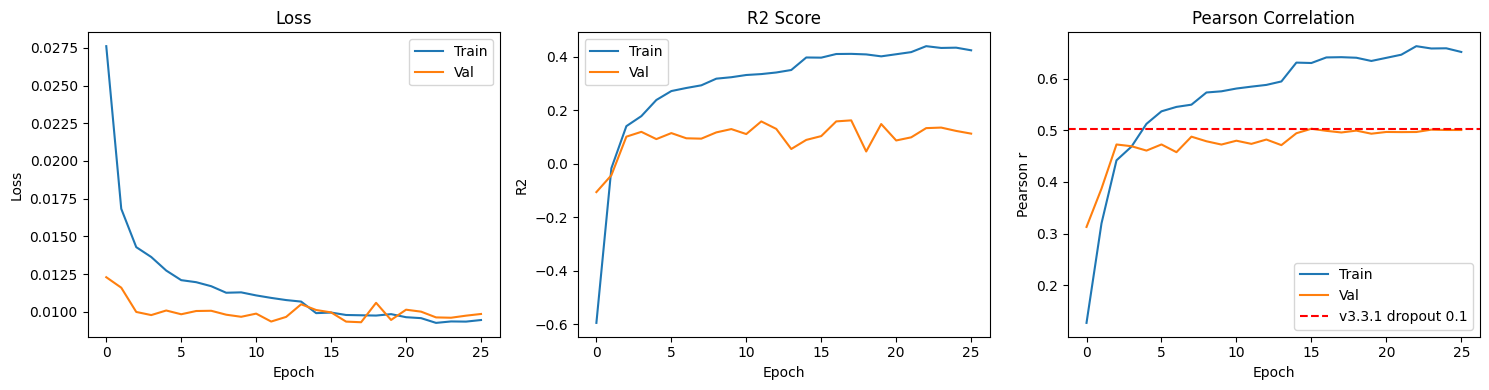

Plot saved to: /content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03/training_history.png


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()

# R2
axes[1].plot(history['train_r2'], label='Train')
axes[1].plot(history['val_r2'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R2')
axes[1].set_title('R2 Score')
axes[1].legend()

# Pearson
axes[2].plot(history['train_pearson'], label='Train')
axes[2].plot(history['val_pearson'], label='Val')
axes[2].axhline(y=0.5019, color='r', linestyle='--', label='v3.3.1 dropout 0.1')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Pearson r')
axes[2].set_title('Pearson Correlation')
axes[2].legend()

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT / 'training_history.png', dpi=150)
plt.show()

print(f"Plot saved to: {DRIVE_OUTPUT / 'training_history.png'}")